# 🏎️ Parameter Tuning Log

Use this notebook to record tuning runs for both solutions.  
Fill in the tables after each run and add data points to the plots as you collect results.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 40)
print("Libraries loaded ✓")

Libraries loaded ✓


---
## Megoldás 1 — Simple Pursuit

**Parameters:**
- **Speed Scale** (`velocity`) — range 0.1 – 3.0  — multiplies the LiDAR-derived adaptive speed (slider × 0.5 = max m/s)
- **Wheelbase Scale** (`wheelbase`) — range 0.5× – 2.0× — scales the measured wheelbase (0.3187 m); higher = wider turns, lower = tighter turns

### Tuning Table

In [2]:
# ── Megoldás 1 tuning table ───────────────────────────────────────────────────
# Edit values directly in this cell and re-run, or add rows manually below.

sol1_data = {
    "Speed Scale (0.1–3.0)":     [None] * 10,
    "Wheelbase Scale (0.5–2.0)": [None] * 10,
    "Lap Time (s)":              [None] * 10,
    "Collision? (yes/no)":       [None] * 10,
    "Notes":                     [""] * 10,
}

sol1_df = pd.DataFrame(sol1_data, index=range(1, 11))
sol1_df.index.name = "Run #"

# Display styled table
sol1_df.style \
    .set_caption("Megoldás 1 — Simple Pursuit — Tuning Log") \
    .set_properties(**{"text-align": "center", "border": "1px solid #ccc", "padding": "6px"}) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"), ("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
    ])

,Speed Scale (0.1–3.0),Wheelbase Scale (0.5–2.0),Lap Time (s),Collision? (yes/no),Notes
Run #,,,,,
1,None,None,None,None,
2,None,None,None,None,
3,None,None,None,None,
4,None,None,None,None,
5,None,None,None,None,
6,None,None,None,None,
7,None,None,None,None,
8,None,None,None,None,
9,None,None,None,None,


### Lap Time vs Parameter Plots

Add data points by editing `sol1_df` above and re-running the plot cell below.

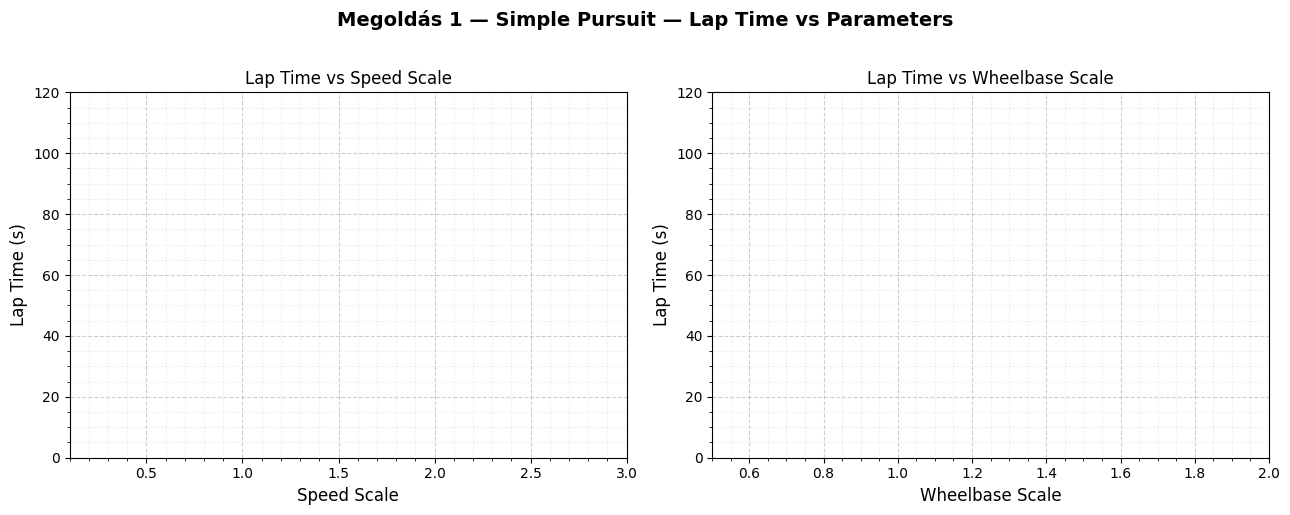

In [3]:
# ── Megoldás 1 — Lap Time plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Megoldás 1 — Simple Pursuit — Lap Time vs Parameters", fontsize=14, fontweight="bold", y=1.02)

param_configs_sol1 = [
    {"col": "Speed Scale (0.1–3.0)",     "xlabel": "Speed Scale",     "xlim": (0.1, 3.0),  "color": "#1f77b4"},
    {"col": "Wheelbase Scale (0.5–2.0)", "xlabel": "Wheelbase Scale", "xlim": (0.5, 2.0),  "color": "#ff7f0e"},
]

for ax, cfg in zip(axes, param_configs_sol1):
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(0, 120)
    ax.set_xlabel(cfg["xlabel"], fontsize=12)
    ax.set_ylabel("Lap Time (s)", fontsize=12)
    ax.set_title(f"Lap Time vs {cfg['xlabel']}", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which="minor", linestyle=":", alpha=0.3)

    # Plot data points from the table if available
    valid = sol1_df[["Lap Time (s)", cfg["col"]]].dropna()
    if not valid.empty:
        x = valid[cfg["col"]].astype(float)
        y = valid["Lap Time (s)"].astype(float)
        ax.scatter(x, y, color=cfg["color"], s=60, zorder=5, label="Runs")
        ax.plot(x.sort_values().values, y[x.argsort()].values,
                color=cfg["color"], alpha=0.4, linewidth=1)
        ax.legend()

plt.tight_layout()
plt.show()

---
## Megoldás 2 — Follow the Gap

**Parameters:**
- **Max Throttle** (`max_throttle`) — range 0.1 – 2.0 m/s — constant forward speed (no dynamic adjustment)
- **Safety Radius** (`safety_radius`) — range 0.2 – 5.0 m — LiDAR readings closer than this are masked out; larger = more conservative
- **Steering Sensitivity** (`steering_sensitivity`) — range 0.1 – 2.0 — multiplies the gap angle to produce steering output; higher = more reactive

### Tuning Table

In [4]:
# ── Megoldás 2 tuning table ───────────────────────────────────────────────────
sol2_data = {
    "Max Throttle (0.1–2.0 m/s)":      [None] * 10,
    "Safety Radius (0.2–5.0 m)":       [None] * 10,
    "Steering Sensitivity (0.1–2.0)":  [None] * 10,
    "Lap Time (s)":                    [None] * 10,
    "Collision? (yes/no)":             [None] * 10,
    "Notes":                           [""] * 10,
}

sol2_df = pd.DataFrame(sol2_data, index=range(1, 11))
sol2_df.index.name = "Run #"

sol2_df.style \
    .set_caption("Megoldás 2 — Follow the Gap — Tuning Log") \
    .set_properties(**{"text-align": "center", "border": "1px solid #ccc", "padding": "6px"}) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1a5276"), ("color", "white"), ("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
    ])

,Max Throttle (0.1–2.0 m/s),Safety Radius (0.2–5.0 m),Steering Sensitivity (0.1–2.0),Lap Time (s),Collision? (yes/no),Notes
Run #,,,,,,
1,None,None,None,None,None,
2,None,None,None,None,None,
3,None,None,None,None,None,
4,None,None,None,None,None,
5,None,None,None,None,None,
6,None,None,None,None,None,
7,None,None,None,None,None,
8,None,None,None,None,None,
9,None,None,None,None,None,


### Lap Time vs Parameter Plots

Add data points by editing `sol2_df` above and re-running the plot cell below.

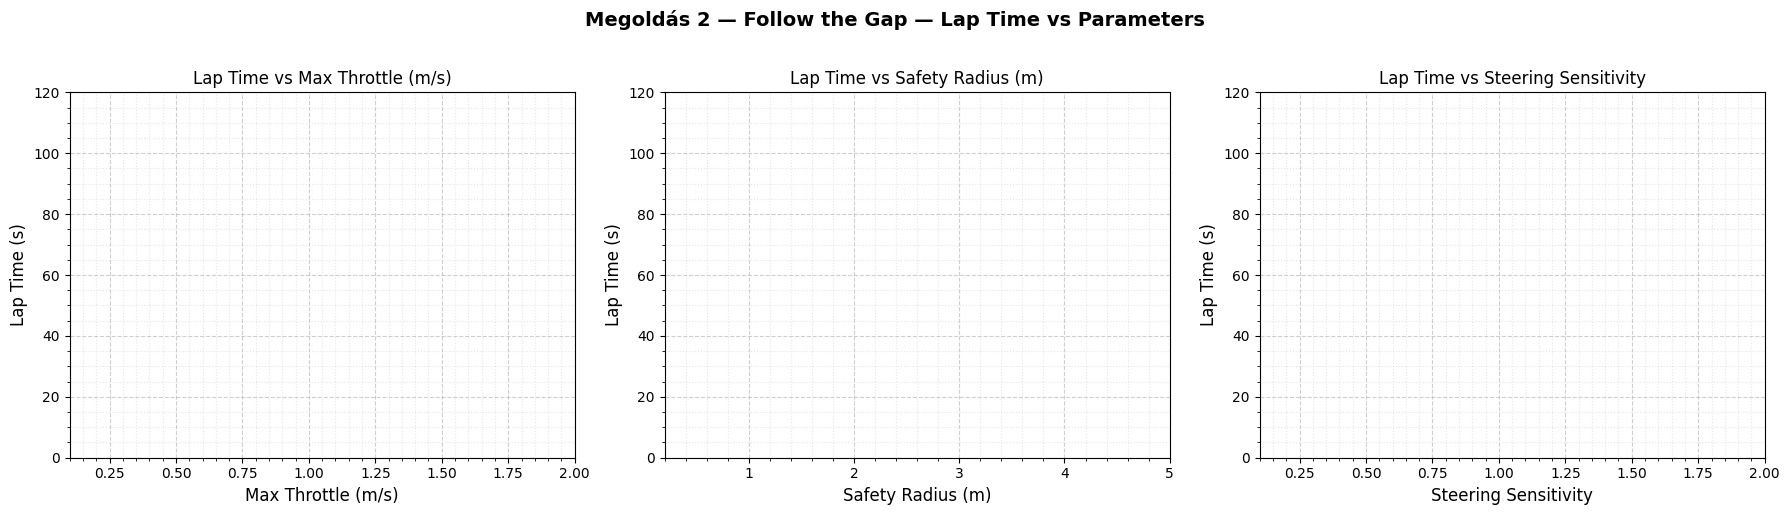

In [5]:
# ── Megoldás 2 — Lap Time plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Megoldás 2 — Follow the Gap — Lap Time vs Parameters", fontsize=14, fontweight="bold", y=1.02)

param_configs_sol2 = [
    {"col": "Max Throttle (0.1–2.0 m/s)",     "xlabel": "Max Throttle (m/s)",     "xlim": (0.1, 2.0), "color": "#2ecc71"},
    {"col": "Safety Radius (0.2–5.0 m)",       "xlabel": "Safety Radius (m)",       "xlim": (0.2, 5.0), "color": "#e74c3c"},
    {"col": "Steering Sensitivity (0.1–2.0)",  "xlabel": "Steering Sensitivity",    "xlim": (0.1, 2.0), "color": "#9b59b6"},
]

for ax, cfg in zip(axes, param_configs_sol2):
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(0, 120)
    ax.set_xlabel(cfg["xlabel"], fontsize=12)
    ax.set_ylabel("Lap Time (s)", fontsize=12)
    ax.set_title(f"Lap Time vs {cfg['xlabel']}", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which="minor", linestyle=":", alpha=0.3)

    # Plot data points from the table if available
    valid = sol2_df[["Lap Time (s)", cfg["col"]]].dropna()
    if not valid.empty:
        x = valid[cfg["col"]].astype(float)
        y = valid["Lap Time (s)"].astype(float)
        ax.scatter(x, y, color=cfg["color"], s=60, zorder=5, label="Runs")
        ax.plot(x.sort_values().values, y[x.argsort()].values,
                color=cfg["color"], alpha=0.4, linewidth=1)
        ax.legend()

plt.tight_layout()
plt.show()